In [1]:
import os, json, random, warnings
import numpy as np
import torch
warnings.filterwarnings("ignore")

import scipy.special
from sklearn.metrics import (
    f1_score, average_precision_score, precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
    Trainer, DataCollatorWithPadding, EarlyStoppingCallback,
)


def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| n_gpu", torch.cuda.device_count())


torch 2.10.0+cu128 | cuda True | n_gpu 2


In [2]:
CFG = {
    "model": "klue/roberta-large",
    "seed": 42,
    "epochs": 5,
    "lr": 1e-5,
    "per_device_train_bs": 16,   # T4x2 기준; OOM 시 8 + grad_accum 2
    "per_device_eval_bs": 64,
    "grad_accum": 2,
    "warmup_ratio": 0.1,          # ★ world_size 자동 반영(기존 warmup 버그 수정)
    "weight_decay": 0.01,
    "max_len": 256,
    "early_stop_patience": 3,
    "run_no_marker": False,       # True 면 no-marker baseline도 학습(G2 결정적 증거, +1런)
    "workdir": "/kaggle/working" if os.path.isdir("/kaggle/working") else ".",
}
set_seed(CFG["seed"])

# effective batch = per_device * n_gpu * grad_accum
_n_gpu = max(1, torch.cuda.device_count())
print("effective batch =", CFG["per_device_train_bs"] * _n_gpu * CFG["grad_accum"],
      f'(={CFG["per_device_train_bs"]} x {_n_gpu}gpu x {CFG["grad_accum"]}accum)')


effective batch = 64 (=16 x 2gpu x 2accum)


In [3]:
ds = load_dataset("klue/klue", "re")
LABELS = ds["train"].features["label"].names      # 30개, index 0 == no_relation
NUM_LABELS = len(LABELS)
NO_RELATION_ID = LABELS.index("no_relation")
print("labels:", NUM_LABELS, "| no_relation id:", NO_RELATION_ID)
print("train/val:", len(ds["train"]), len(ds["validation"]))


README.md: 0.00B [00:00, ?B/s]

re/train-00000-of-00001.parquet:   0%|          | 0.00/6.65M [00:00<?, ?B/s]

re/validation-00000-of-00001.parquet:   0%|          | 0.00/1.54M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32470 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7765 [00:00<?, ? examples/s]

labels: 30 | no_relation id: 0
train/val: 32470 7765


In [4]:
def add_markers(example: dict) -> str:
    """typed punctuation marker (Zhou & Chen 2022 scheme): subj @*TYPE*word@, obj #^TYPE^word#."""
    text = example["sentence"]
    subj, obj = example["subject_entity"], example["object_entity"]
    spans = [
        (subj["start_idx"], subj["end_idx"], subj["type"], "subj"),
        (obj["start_idx"], obj["end_idx"], obj["type"], "obj"),
    ]
    spans.sort(key=lambda s: s[0], reverse=True)   # 뒤에서부터 삽입(인덱스 보존)
    for start, end, etype, role in spans:
        word = text[start:end + 1]
        tag = f"@*{etype}*{word}@" if role == "subj" else f"#^{etype}^{word}#"
        text = text[:start] + tag + text[end + 1:]
    return text


def plain_text(example: dict) -> str:
    """no-marker baseline: 원문 그대로(엔티티 텍스트는 유지, 표시만 제거)."""
    return example["sentence"]


def build_text(example: dict, use_marker: bool) -> str:
    return add_markers(example) if use_marker else plain_text(example)


In [ ]:
def official_micro_f1(labels: np.ndarray, preds: np.ndarray) -> float:
    """공식 KLUE: no_relation 클래스만 averaging에서 제외(labels 1..29"""
    rel = [i for i in range(NUM_LABELS) if i != NO_RELATION_ID]
    return float(f1_score(labels, preds, labels=rel, average="micro", zero_division=0))


def legacy_micro_f1(labels: np.ndarray, preds: np.ndarray) -> float:
    """비표준(과거 노트북): true==no_relation 행을 삭제 후 micro-F1 ."""
    m = labels != NO_RELATION_ID
    if m.sum() == 0:
        return 0.0
    return float(f1_score(labels[m], preds[m], average="micro", zero_division=0))


def auprc(labels: np.ndarray, logits: np.ndarray) -> float:
    """공식 KLUE AUPRC: no_relation 제외 클래스 micro AP."""
    probs = scipy.special.softmax(logits, axis=1)
    onehot = label_binarize(labels, classes=list(range(NUM_LABELS)))
    rel = [i for i in range(NUM_LABELS) if i != NO_RELATION_ID]
    return float(average_precision_score(onehot[:, rel], probs[:, rel], average="micro"))


def metrics_fn(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "micro_f1": official_micro_f1(labels, preds),   
        "legacy_f1": legacy_micro_f1(labels, preds),
        "auprc": auprc(labels, logits),
    }


In [ ]:
def train_and_eval(use_marker: bool, tag: str):
    set_seed(CFG["seed"])
    tok = AutoTokenizer.from_pretrained(CFG["model"])

    def tokenize(batch):  
        texts = [build_text({"sentence": s, "subject_entity": se, "object_entity": oe}, use_marker)
                 for s, se, oe in zip(batch["sentence"], batch["subject_entity"], batch["object_entity"])]
        enc = tok(texts, truncation=True, max_length=CFG["max_len"])
        enc["labels"] = batch["label"]
        return enc

    train_ds = ds["train"].map(tokenize, batched=True, remove_columns=ds["train"].column_names)
    val_ds = ds["validation"].map(tokenize, batched=True, remove_columns=ds["validation"].column_names)

    model = AutoModelForSequenceClassification.from_pretrained(
        CFG["model"], num_labels=NUM_LABELS)

    args = TrainingArguments(
        output_dir=os.path.join(CFG["workdir"], f"ckpt_{tag}"),
        num_train_epochs=CFG["epochs"],
        per_device_train_batch_size=CFG["per_device_train_bs"],
        per_device_eval_batch_size=CFG["per_device_eval_bs"],
        gradient_accumulation_steps=CFG["grad_accum"],
        learning_rate=CFG["lr"],
        warmup_ratio=CFG["warmup_ratio"],
        weight_decay=CFG["weight_decay"],
        lr_scheduler_type="linear",
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="micro_f1", greater_is_better=True,
        fp16=True, seed=CFG["seed"], data_seed=CFG["seed"],
        logging_steps=100, save_total_limit=2, report_to="none",  # best+last 보존
        dataloader_num_workers=2,
    )
    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        processing_class=tok, data_collator=DataCollatorWithPadding(tok),
        compute_metrics=metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=CFG["early_stop_patience"])],
    )
    trainer.train()
    pred = trainer.predict(val_ds)
    logits = pred.predictions
    labels = np.array(val_ds["labels"])
    np.save(os.path.join(CFG["workdir"], f"val_logits_{tag}.npy"), logits)
    np.save(os.path.join(CFG["workdir"], f"val_labels_{tag}.npy"), labels)
    return logits, labels


In [7]:
logits_m, y = train_and_eval(use_marker=True, tag="marker")
p_m = logits_m.argmax(1)
print(f"[marker] 공식 micro-F1 = {official_micro_f1(y, p_m):.4f}")
print(f"[marker] legacy  F1   = {legacy_micro_f1(y, p_m):.4f}  (부풀림 비교용)")
print(f"[marker] AUPRC        = {auprc(y, logits_m):.4f}")


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Map:   0%|          | 0/32470 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

[marker] 공식 micro-F1 = 0.7037
[marker] legacy  F1   = 0.7368  (부풀림 비교용)
[marker] AUPRC        = 0.7578


In [ ]:
def error_composition(y: np.ndarray, p: np.ndarray) -> dict:
    over = int(((y == NO_RELATION_ID) & (p != NO_RELATION_ID)).sum())   # 없는데 있다고
    miss = int(((y != NO_RELATION_ID) & (p == NO_RELATION_ID)).sum())   # 있는데 없다고
    swap = int(((y != NO_RELATION_ID) & (p != NO_RELATION_ID) & (y != p)).sum())  # 종류 틀림
    total = over + miss + swap
    boundary = over + miss
    return {"over_detect": over, "miss": miss, "type_swap": swap,
            "total": total, "boundary": boundary,
            "boundary_frac": boundary / total if total else 0.0}


def type_accuracy_given_relation(y: np.ndarray, p: np.ndarray) -> float:
    m = (y != NO_RELATION_ID) & (p != NO_RELATION_ID)
    return float((y[m] == p[m]).mean()) if m.sum() else 0.0


comp = error_composition(y, p_m)
type_acc = type_accuracy_given_relation(y, p_m)

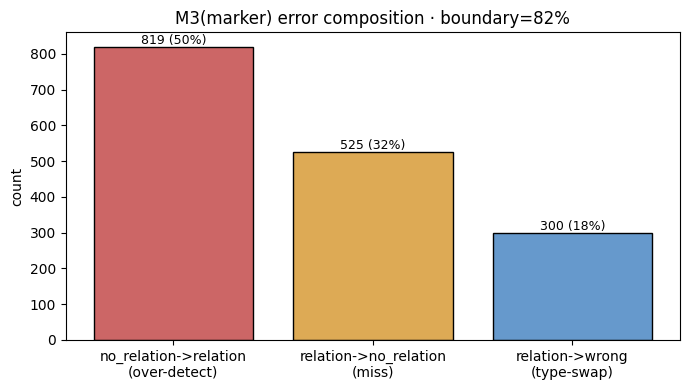

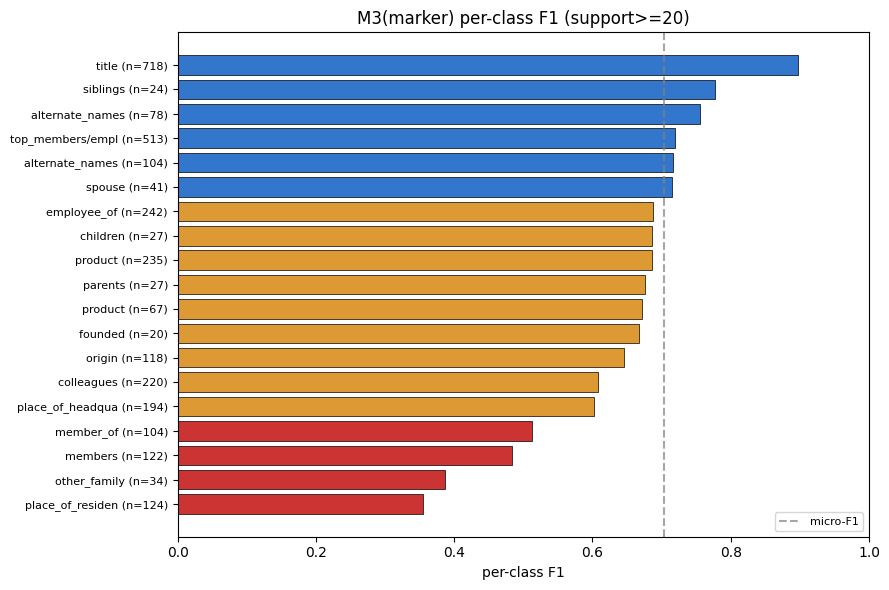

In [9]:
# 그림 1: 에러 구성
fig, ax = plt.subplots(figsize=(7, 4))
cats = ["no_relation->relation\n(over-detect)", "relation->no_relation\n(miss)",
        "relation->wrong\n(type-swap)"]
vals = [comp["over_detect"], comp["miss"], comp["type_swap"]]
bars = ax.bar(cats, vals, color=["#cc6666", "#ddaa55", "#6699cc"], edgecolor="black")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.01,
            f"{v} ({v/comp['total']*100:.0f}%)", ha="center", fontsize=9)
ax.set_ylabel("count"); ax.set_title(f"M3(marker) error composition · boundary={frac:.0%}")
plt.tight_layout(); plt.savefig(os.path.join(CFG["workdir"], "g2_error_composition.png"), dpi=130)
plt.show()

# 그림 2: 클래스별 F1 (support>=20)
pr, rc, fc, sup = precision_recall_fscore_support(
    y, p_m, labels=list(range(NUM_LABELS)), zero_division=0)
keep = sorted([i for i in range(NUM_LABELS) if sup[i] >= 20 and i != NO_RELATION_ID],
              key=lambda i: fc[i])
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#cc3333" if fc[i] < 0.55 else "#dd9933" if fc[i] < 0.7 else "#3377cc" for i in keep]
ax.barh(range(len(keep)), [fc[i] for i in keep], color=colors, edgecolor="black", lw=0.5)
ax.set_yticks(range(len(keep)))
ax.set_yticklabels([f"{LABELS[i].split(':')[-1][:16]} (n={sup[i]})" for i in keep], fontsize=8)
ax.set_xlim(0, 1); ax.set_xlabel("per-class F1")
ax.axvline(official_micro_f1(y, p_m), color="gray", ls="--", alpha=0.7, label="micro-F1")
ax.legend(fontsize=8); ax.set_title("M3(marker) per-class F1 (support>=20)")
plt.tight_layout(); plt.savefig(os.path.join(CFG["workdir"], "g2_per_class_f1.png"), dpi=130)
plt.show()


In [10]:
if CFG["run_no_marker"]:
    logits_n, _ = train_and_eval(use_marker=False, tag="nomarker")
    p_n = logits_n.argmax(1)
    print(f"[no-marker] 공식 micro-F1 = {official_micro_f1(y, p_n):.4f}")
    print(f"[gain] marker - no_marker = "
          f"{official_micro_f1(y, p_m) - official_micro_f1(y, p_n):+.4f}")

    comp_n = error_composition(y, p_n)
    print("no-marker 에러 분해:", comp_n)
    print(f"경계 오류 감소: over {comp_n['over_detect']-comp['over_detect']:+d}, "
          f"miss {comp_n['miss']-comp['miss']:+d}, swap {comp_n['type_swap']-comp['type_swap']:+d}")

    _, _, fc_m, sup = precision_recall_fscore_support(
        y, p_m, labels=list(range(NUM_LABELS)), zero_division=0)
    _, _, fc_n, _ = precision_recall_fscore_support(
        y, p_n, labels=list(range(NUM_LABELS)), zero_division=0)
    delta = {LABELS[i]: round(float(fc_m[i]-fc_n[i]), 3)
             for i in range(NUM_LABELS) if sup[i] >= 20}
    print("\\n클래스별 F1 이득(marker-no_marker), 큰 순:")
    for k, v in sorted(delta.items(), key=lambda x: -x[1]):
        print(f"  {v:+.3f}  {k}")
    print("\\n해석: no_relation 및 경계 인접 관계에서 이득이 크면 → G2 채택(경계 집중).")
else:
    print("run_no_marker=False. 결정적 G2 증거가 필요하면 True로 켜고 재실행(+1런).")


run_no_marker=False. 결정적 G2 증거가 필요하면 True로 켜고 재실행(+1런).


In [11]:
summary = {
    "model": CFG["model"], "seed": CFG["seed"],
    "official_micro_f1": round(official_micro_f1(y, p_m), 4),
    "legacy_micro_f1": round(legacy_micro_f1(y, p_m), 4),
    "auprc": round(auprc(y, logits_m), 4),
    "error_composition": comp,
    "type_acc_given_relation": round(type_acc, 4),
    "G2_boundary_frac": round(frac, 4),
    "G2_verdict": verdict,
}
with open(os.path.join(CFG["workdir"], "g2_summary.json"), "w") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "model": "klue/roberta-large",
  "seed": 42,
  "official_micro_f1": 0.7037,
  "legacy_micro_f1": 0.7368,
  "auprc": 0.7578,
  "error_composition": {
    "over_detect": 819,
    "miss": 525,
    "type_swap": 300,
    "total": 1644,
    "boundary": 1344,
    "boundary_frac": 0.8175182481751825
  },
  "type_acc_given_relation": 0.885,
  "G2_boundary_frac": 0.8175,
  "G2_verdict": "STRONG: no_relation 경계가 에러의 대부분 → marker 이득이 경계 해소에 집중될 가능성 큼"
}
